In [2]:
from kernel_model.data import load_patches_from_folders
from kernel_model.data import *
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
import os
import shutil

### Visualize patches

In [3]:
X_in, X_out = load_patches_from_folders(
    Path('data/patches'),
    max_per_class=2000,
    resize=(64, 64)
)

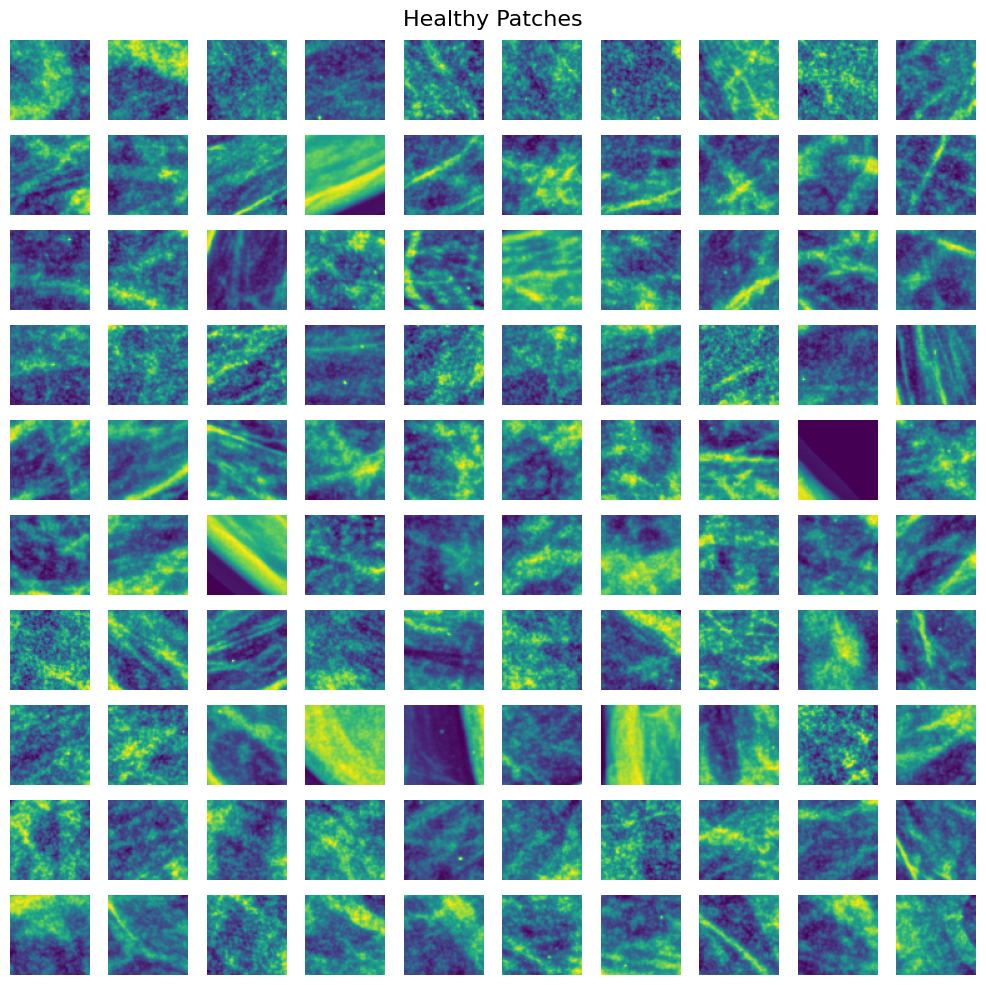

In [4]:
n = 100
fig = plt.figure(figsize=(10, 10))

for i in range(n):
    ax = fig.add_subplot(10, 10, i + 1)
    ax.imshow(X_out[i])
    ax.axis('off')

fig.suptitle("Healthy Patches", fontsize=16)
plt.tight_layout()
plt.show()


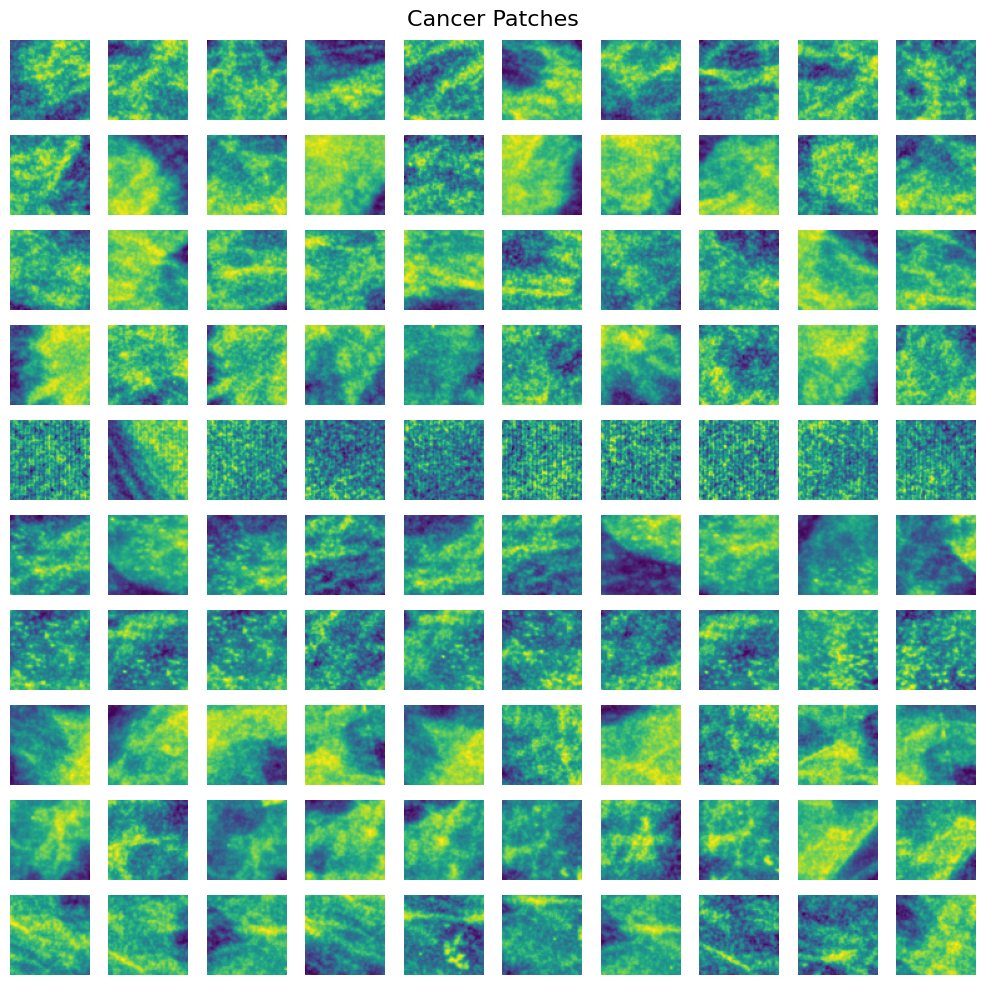

In [5]:
n = 100
fig = plt.figure(figsize=(10, 10))

for i in range(n):
    ax = fig.add_subplot(10, 10, i + 1)
    ax.imshow(X_in[i])
    ax.axis('off')

fig.suptitle("Cancer Patches", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
annot = cv2.imread(str('/home/masoud/Uni/Kernel Based Cancer Classification/data/TIFF Images/malignantAnnotation/IMG001.tif'), cv2.IMREAD_COLOR_RGB)
mask = get_malignant_mask(annot, red_threshold=150, low_threshold=75).astype(np.uint8)
plt.imshow(mask)

ValueError: too many values to unpack (expected 3)

0


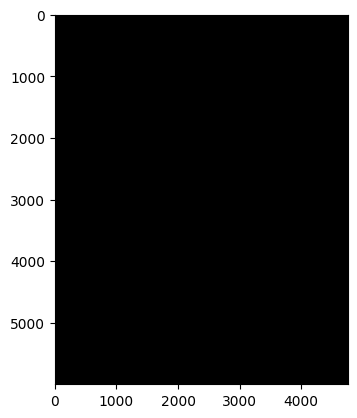

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


img_path = Path('/home/masoud/Uni/Kernel Based Cancer Classification/temp_mask.png')
img = Image.open(img_path).convert('RGB')
img = np.array(img)
print(img.max())
img = np.array(img)
# (img > 0).mean() < 0.35
plt.imshow(img)

### Split data

In [1]:
from kernel_model.data import *
from pathlib import Path
from shutil import rmtree

rmtree('data/patches', ignore_errors=True)

extract_patches(healthy_dir=Path('data/TIFF Images/Normal'),
        malignant_dir=Path('data/TIFF Images/Malignant'),
        annotation_dir=Path('data/TIFF Images/malignantAnnotation'),
        output_dir=Path('data/patches'),
        patch_size=128,
        n_inside_per_image=10,
        n_outside_per_image=10,
        red_threshold=150,
        max_tries=250,
        min_nonzero_frac=0.35,)

Extracting patches: 100%|██████████| 125/125 [49:09<00:00, 23.59s/it]


(1230, 1250)

In [34]:
pt = Path("data/TIFF Images/Malignant")
pt1 = Path("data/TIFF Images/malignantAnnotation")

pt_files = {p.name for p in pt.glob("*.tif")}
pt1_files = {p.name for p in pt1.glob("*.tif")}

missing = pt_files - pt1_files
print(missing)

set()


In [ ]:
malignant = Path('data/TIFF Images/Malignant')